# 05: Execution-based metrics

Does the translation preserve semantics? Oracle = the gold **SQL on Postgres**; compared against the generated query run on the graph DB, as multisets (Execution Accuracy / precision / recall / F1 / Jaccard). Prerequisites:

- graphonauts **Postgres** up (port 5433, db/user `graphonaut`) loaded with LDBC SF1.
- **Neo4j** up (`bolt://localhost:7687`, `NEO4J_PASSWORD`) loaded with LDBC SF1 (Cypher target).
- **ArangoDB** up (`http://localhost:8529`, db **`graphonauts`**, `ARANGO_PASSWORD`) loaded with LDBC SF1 (AQL target). **After every (re)load run `eval/scripts/build_arango_unified_edges.py`** to build the mapping-aligned unified edge collections (`KNOWS`, `HAS_CREATOR`, `HAS_TAG`, ...); without them every AQL traversal errors and execution accuracy is 0.
- **Gremlin Server** up (`ws://localhost:8182/gremlin`, TraversalSource `g`) with graphonauts's in-memory TinkerGraph loaded (Gremlin target). TinkerGraph lives on the JVM heap: run it with Neo4j and ArangoDB **stopped**, and reload after any container restart (`uv run graphonauts load gremlin` in graphonauts; see its `docs/gremlin/LOADING_BRIEF.md`).
- **Datetime**: Neo4j stores `creationDate`/`birthday`/`joinDate` as native temporals; ArangoDB and TinkerGraph store them as ISO-8601 strings. Both are reconciled to epoch-millis by `harness.execution.to_epoch_ms` against the columns the Postgres oracle reports as dates.

Because the graph DBs cannot all run at once (memory), execution is **per target**: `EVAL_EXECUTION_TARGETS` (default `cypher,aql,gremlin`) selects which targets execute this pass, and the save cell **merges** into `metrics_execution.csv` so the other targets' rows are preserved. Export the passwords for the backends you run (`NEO4J_PASSWORD` / `ARANGO_PASSWORD` / `POSTGRES_PASSWORD`); they are asserted lazily per target. Comparison is **positional** (RETURN column order must match the SQL SELECT order). Cypher, AQL, and Gremlin results are reported in separate subsections below (never mixed).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import json
import os

import pandas as pd
from harness import EXECUTION_CACHE_PATH, METRICS_EXECUTION_CSV, RECORDS_DIR, THINKING_LABELS, load_records

OUT_CSV = METRICS_EXECUTION_CSV
CACHE_PATH = EXECUTION_CACHE_PATH
from harness import plots

## Connection configs and DB availability map

Which `(dataset, target)` cells can be executed: the dataset needs a Postgres oracle, the target needs a graph DB. `cypher` runs on Neo4j, `aql` on ArangoDB (db `graphonauts`). DB passwords are asserted lazily per target on first use, so a Cypher-only or AQL-only subset needs only that backend up.

In [2]:
from harness import execution as ex

# Connection config, the comparator, and the per-backend executors live in
# harness.execution, shared with eval/scripts/validate_gold.py. Targets executed
# THIS pass; every other target's rows in metrics_execution.csv are preserved by
# the merge in the save cell (the backends cannot all run at once).
EXEC_TARGETS = [t.strip() for t in os.environ.get('EVAL_EXECUTION_TARGETS', 'cypher,aql,gremlin').split(',') if t.strip()]
print(f'Backends: {ex.TARGET_DB} | per-query timeout: {ex.TIMEOUT_S}s | executing: {EXEC_TARGETS}')


Backends: {'cypher': 'neo4j', 'aql': 'arangodb', 'gremlin': 'gremlin'} | per-query timeout: 180s | executing: ['cypher', 'aql', 'gremlin']


## Comparator and executors

The row normalisation, the date-reconciling multiset comparator, and the per-backend
executors (including the Gremlin daemon-thread-per-query workaround) live in
`harness.execution`, shared with `eval/scripts/validate_gold.py` so the gold proof and
the model scoring can never drift. Passwords are asserted lazily per target on first
use, so a subset run only needs that backend up.

## Reference-row cache

Keyed by `(dataset, query_id)` so the same query id across datasets does not collide. Delete `execution_rows_cache.json` to refresh.

In [3]:
cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
print(f'Reference cache: {len(cache)} entries.')

Reference cache: 15 entries.


## Execution, per target

Each `### <model>` subsection calls `run_model(target, model, <target>_frames)`, which executes **only that model's** queries for the target against its graph DB (via `execute_model`) and stashes the metric rows in the target's bucket. The `### Visualizations` cell concatenates the bucket into `<target>_exec_df` for the plot and aggregation. A target not listed in `EVAL_EXECUTION_TARGETS` is skipped (`run_model` returns `None`) and keeps its existing rows in `metrics_execution.csv`. The Postgres oracle rows are cached per `(dataset, query_id)`, so whichever model runs a query first populates the cache and the rest reuse it.

In [4]:
records = load_records(RECORDS_DIR)
print(f'Loaded {len(records)} record(s); targets selected for execution: {EXEC_TARGETS}')

def execute_model(target, model):
    """Execute one model's queries for `target` (None if the target is skipped this pass)."""
    if target not in EXEC_TARGETS:
        print(f'{target}: skipped (not in EVAL_EXECUTION_TARGETS); existing rows are preserved.')
        return None
    recs = [r for r in records if r['model'] == model]
    return ex.execute_records(recs, target, cache, CACHE_PATH)

EXEC_COLS = ['query_id', 'difficulty', 'execution_accuracy', 'result_precision', 'result_recall',
             'result_f1', 'result_jaccard_dist', 'execution_error', 'translated_runtime_s',
             'reference_rows', 'translated_rows']
EXEC_METRIC_COLS = ['execution_accuracy', 'result_precision', 'result_recall', 'result_f1', 'result_jaccard_dist']

def show_model(frame, model):
    """Per-query execution results for one model (frame = one target's metric rows)."""
    if frame is None:
        print('Target skipped this pass.')
        return None
    sub = frame[frame['model'] == model]
    if not len(sub):
        print(f'No executed records for {model}.')
        return None
    return sub[EXEC_COLS].sort_values('query_id').reset_index(drop=True)

def summarize_target(frame):
    """Mean execution metrics by model (frame = one target's metric rows)."""
    if frame is None:
        print('Target skipped this pass.')
        return None
    return frame.groupby('model')[EXEC_METRIC_COLS].mean()


def run_model(target, model, bucket):
    """Execute one model for `target`, stash its rows in `bucket`, return its per-query table."""
    f = execute_model(target, model)
    if f is None:
        return None  # target skipped this pass
    if not len(f):
        print(f'No executed records for {model}.')
        return None
    bucket.append(f)
    return f.sort_values('query_id')[EXEC_COLS].reset_index(drop=True)


Loaded 225 record(s); targets selected for execution: ['cypher', 'aql', 'gremlin']


## SQL → Cypher

In [5]:
cypher_frames = []  # per-model execution rows for this target

### llama3.2:latest

In [6]:
run_model('cypher', 'llama3.2:latest', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) EXEC ERROR (CypherSyntaxError: {neo4j_code: Neo.ClientError.Statement.Sy)
[  3/15] ldbc_q03 (cypher) ne EX=0 F1=0.00 ref=4 trans=0
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `tag_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=4, column=34, offset=115>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 115, 'line': 4, 'column': 34}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (t:Tag)\nWITH t, COLLECT(DISTINCT {tag_id: t.id}) as tags\nUNWIND tags AS tag\nOPTIONAL MATCH (mt:Tag) WHERE mt.tag_id = tag.tag_id\nRETURN t.id, t.name, COUNT(DISTINCT mt) as usage_count\nORDER BY usage_count DESC\nLIMIT 20'


ne EX=0 F1=0.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `person_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=26, offset=53>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 53, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p1:Person {id: 933})\nOPTIONAL MATCH (k:Knows {person_id: p1.id})\nOPTIONAL MATCH (p2:Person {id: k.friend_id})\nRETURN p2.id, p2.firstName, p2.lastName, k.creationDate AS friendship_date'
Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `K

ne EX=0 F1=0.00 ref=5 trans=1
[  7/15] ldbc_q07 (cypher) 

...

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `person_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=35, offset=72>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 72, 'line': 2, 'column': 35}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Person)-[:KNOWS]->(k:Person)\nWHERE NOT (p)-[:KNOWS]->(k) AND k.person_id = p.id\nWITH p, count(k) AS friend_count\nRETURN p.id, p.firstName, p.lastName, friend_count\nORDER BY friend_count DESC\nLIMIT 10;'


ne EX=0 F1=0.00 ref=5407 trans=0
[ 12/15] ldbc_q12 (cypher) EXEC ERROR (CypherSyntaxError: {neo4j_code: Neo.ClientError.Statement.Sy)
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Country` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=10, offset=9>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 1, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (c:Country {name: 'country_name'})\nOPTIONAL MATCH (p:Person)-[:IS_LOCATED_IN]->(c)\nWITH c, COUNT(p) AS person_count\nRETURN c.name AS country_name, person_count"


ne EX=0 F1=0.00 ref=111 trans=0
[ 15/15] ldbc_q15 (cypher) ne EX=0 F1=0.00 ref=3 trans=1


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.116487,1,1
1,ldbc_q02,easy,0.0,0.000000,0.000000,0.000000,1.00000,CypherSyntaxError: {neo4j_code: Neo.ClientErro...,0.018313,12932,0
2,ldbc_q03,easy,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.009741,4,0
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,2.679421,10,10
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.00000,NaN,21.109039,20,20
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.195649,5,1
6,ldbc_q07,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.325462,58,0
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.00000,NaN,1.600575,2805,0
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.235443,20,0
9,ldbc_q10,hard,0.0,0.121801,0.121801,0.121801,0.93515,NaN,5.658660,90492,90492


### qwen3-coder:30b

In [7]:
run_model('cypher', 'qwen3-coder:30b', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) EXEC ERROR (ClientError: {neo4j_code: Neo.ClientError.Transaction.Transa)
[  6/15] ldbc_q06 (cypher) ne EX=0 F1=0.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `replyOfPostId` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=9, offset=53>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 53, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (c:Comment)-[:HAS_CREATOR]->(p:Person)\nWHERE c.replyOfPostId = 412317942891\nRETURN c.id AS comment_id, c.content, c.creationDate, p.firstName, p.lastName\nORDER BY c.creationDate DESC'


ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (cypher) ne EX=0 F1=0.12 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `forum_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=10, offset=52>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 52, 'line': 2, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Person)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 137439023186\nRETURN DISTINCT p.id, p.firstName, p.lastName\nUNION\nMATCH (p:Person)-[:LIKES]->(l:Post)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 137439023186\nRETURN DISTINCT p.id, p.firstName, p.lastName'
Received notification from DBMS server: <GqlStatusObject g

ne EX=0 F1=0.00 ref=917 trans=0
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ne EX=0 F1=0.00 ref=111 trans=0
[ 15/15] ldbc_q15 (cypher) 

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=2, column=1, offset=26>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 26, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Place {id: 111})\nCALL {\n    WITH p\n    MATCH path = (p)-[:IS_PART_OF*]->(descendant:Place)\n    UNWIND nodes(path) AS node\n    WITH DISTINCT node\n    RETURN node.id AS id, node.name AS name, node.type AS type, 1 AS depth\n}\nWITH p\nMATCH path = (p)-[:IS_PART_OF*]->(descendant:Place)\nUNWIND nodes(path) AS node\nWITH DISTINCT no

ne EX=0 F1=0.33 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.059768,1,1
1,ldbc_q02,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,2.007366,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.047261,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,1.001196,10,10
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.00000,ClientError: {neo4j_code: Neo.ClientError.Tran...,180.069145,20,0
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.054952,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.092108,58,58
7,ldbc_q08,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.379503,2805,2805
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.180981,20,0
9,ldbc_q10,hard,0.0,0.121801,0.121801,0.121801,0.93515,NaN,4.827761,90492,90492


### gemma4:26b

In [8]:
run_model('cypher', 'gemma4:26b', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.006342,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,1.654404,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.011595,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,2.604696,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,2.355844,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.057591,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.081212,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,0.306842,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.092840,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,5.416159,90492,90492


### claude-opus-4-8

In [9]:
run_model('cypher', 'claude-opus-4-8', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.006055,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,1.965782,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.010297,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,2.739863,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,2.307386,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.055378,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.025910,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,0.209157,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.073514,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,5.330624,90492,90492


### claude-opus-4-8-thinking

In [10]:
run_model('cypher', 'claude-opus-4-8-thinking', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.006045,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,1.689386,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.037207,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,2.966067,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,2.366217,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.005851,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.009044,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,0.302951,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.072711,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,5.265576,90492,90492


### Visualizations

SQL -> Cypher: 5 model(s), 15 query id(s)


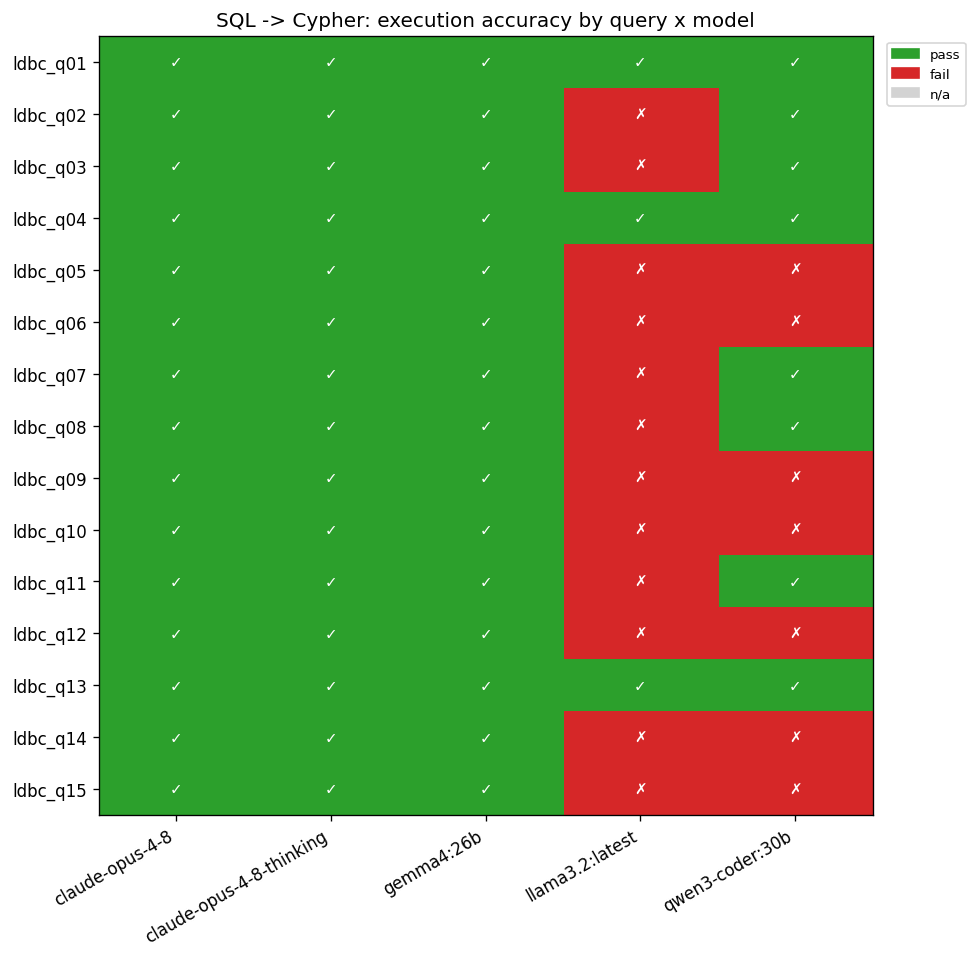

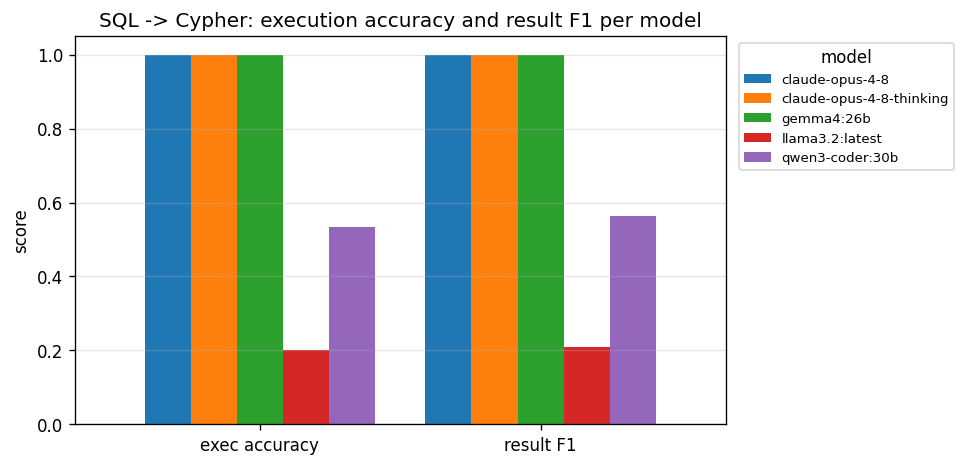

In [11]:
cypher_exec_df = pd.concat(cypher_frames, ignore_index=True) if cypher_frames else None
plots.render_target(cypher_exec_df, 'cypher', 'SQL -> Cypher', plots.FIGURE_SETS['execution'])

### Aggregation by model

In [12]:
summarize_target(cypher_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
claude-opus-4-8,1.000000,1.000000,1.000000,1.000000,0.000000
claude-opus-4-8-thinking,1.000000,1.000000,1.000000,1.000000,0.000000
gemma4:26b,1.000000,1.000000,1.000000,1.000000,0.000000
llama3.2:latest,0.200000,0.208120,0.208120,0.208120,0.795677
qwen3-coder:30b,0.533333,0.563676,0.563676,0.563676,0.449010


## SQL → AQL

In [23]:
aql_frames = []  # per-model execution rows for this target

### llama3.2:latest

In [24]:
run_model('aql', 'llama3.2:latest', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  2/15] ldbc_q02 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  3/15] ldbc_q03 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  4/15] ldbc_q04 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  5/15] ldbc_q05 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 400][ERR 1512] use of unknown va)
[  6/15] ldbc_q06 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  7/15] ldbc_q07 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  8/15] ldbc_q08 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  9/15] ldbc_q09 (aql) skip (translation invalid)
[ 10/15] ldbc_q10 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[ 11/15] ldbc_q11 (aql) EXEC ERROR (A

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003564,1,0
1,ldbc_q02,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004243,12932,0
2,ldbc_q03,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003211,4,0
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004197,10,0
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 400][ERR 1512] use...,0.004739,20,0
5,ldbc_q06,medium,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004062,5,0
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003567,58,0
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.005674,2805,0
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
9,ldbc_q10,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004918,90492,0


### qwen3-coder:30b

In [25]:
run_model('aql', 'qwen3-coder:30b', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ne EX=0 F1=0.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ne EX=0 F1=0.00 ref=20 trans=0
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ne EX=0 F1=0.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ne EX=0 F1=0.00 ref=2805 trans=21084
[  9/15] ldbc_q09 (aql) ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ne EX=0 F1=0.00 ref=111 trans=0
[ 15/15] ldbc_q15 (aql) ne EX=0 F1=0.00 ref=3 trans=2


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.007226,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.110507,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.006238,4,4
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,None,15.473179,10,10
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,None,0.110177,20,0
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006268,5,5
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,None,0.011097,58,58
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,None,52.124565,2805,21084
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,None,5.491943,20,0
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,15.697099,90492,90492


### gemma4:26b

In [26]:
run_model('aql', 'gemma4:26b', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.007902,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.139880,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.005995,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,0.965922,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,47.045849,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006081,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.016040,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,27.969112,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,48.404313,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,1.316921,90492,90492


### claude-opus-4-8

In [27]:
run_model('aql', 'claude-opus-4-8', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.008261,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.111396,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.006466,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,14.317603,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,116.433808,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006445,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.010128,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,24.723461,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,46.966281,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,15.176524,90492,90492


### claude-opus-4-8-thinking

In [28]:
run_model('aql', 'claude-opus-4-8-thinking', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.007397,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.102435,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.005945,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,14.969982,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,43.441771,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006763,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.010478,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,25.936799,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.244174,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,18.086638,90492,90492


### Visualizations

SQL -> AQL: 5 model(s), 15 query id(s)


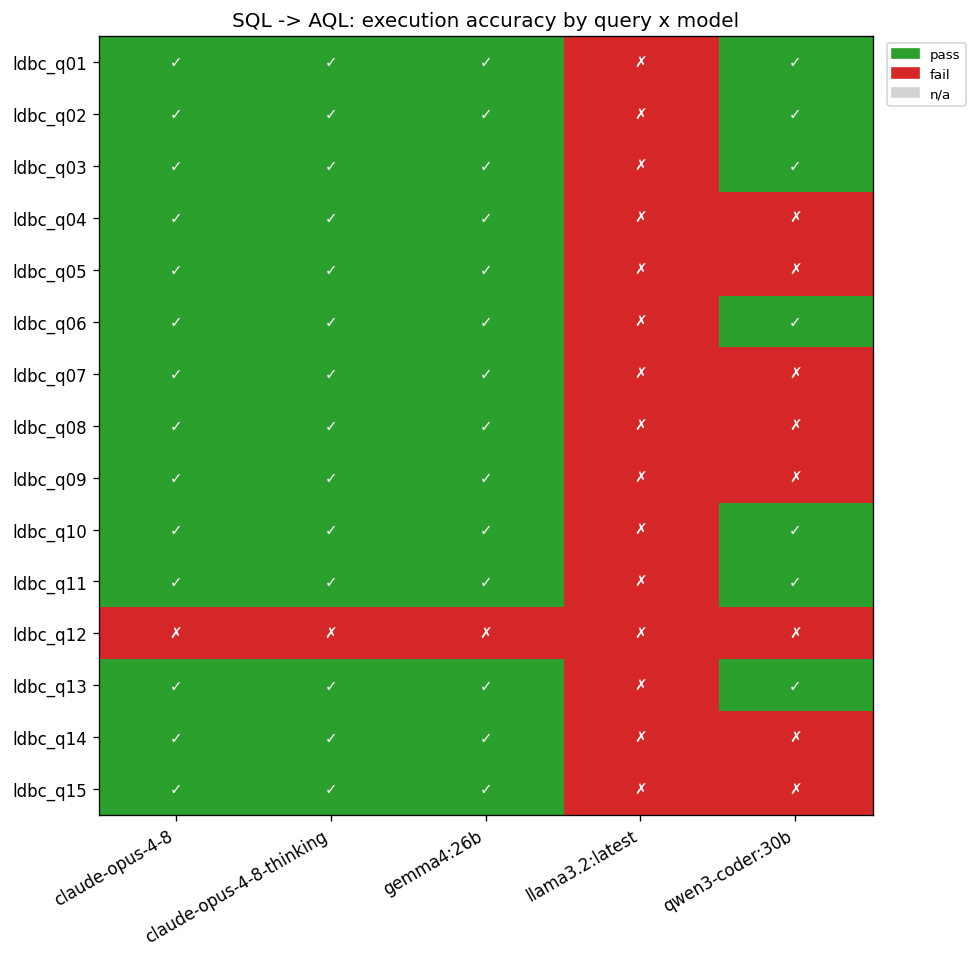

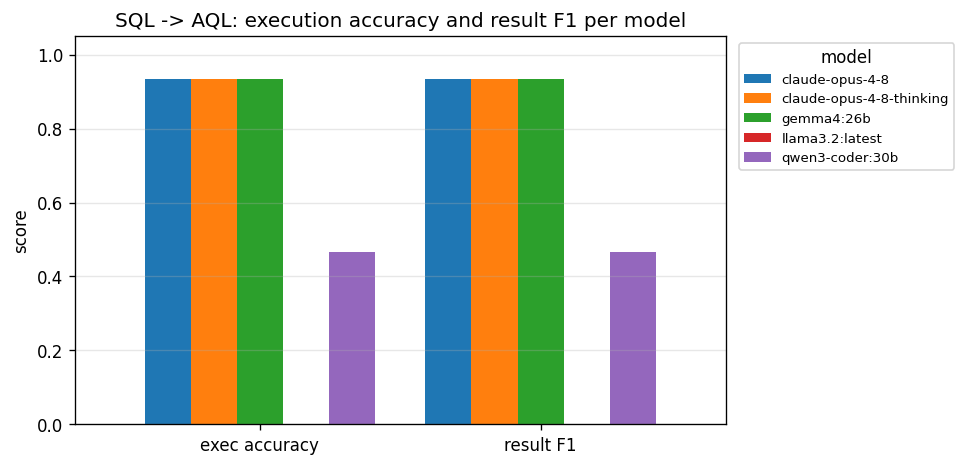

In [29]:
aql_exec_df = pd.concat(aql_frames, ignore_index=True) if aql_frames else None
plots.render_target(aql_exec_df, 'aql', 'SQL -> AQL', plots.FIGURE_SETS['execution'])

### Aggregation by model

In [31]:
summarize_target(aql_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
claude-opus-4-8,0.933333,0.933333,0.933333,0.933333,0.066667
claude-opus-4-8-thinking,0.933333,0.933333,0.933333,0.933333,0.066667
gemma4:26b,0.933333,0.933333,0.933333,0.933333,0.066667
llama3.2:latest,0.000000,0.000000,0.000000,0.000000,1.000000
qwen3-coder:30b,0.466667,0.466667,0.466667,0.466667,0.533333


## SQL → Gremlin

In [32]:
gremlin_frames = []  # per-model execution rows for this target

### llama3.2:latest

In [33]:
run_model('gremlin', 'llama3.2:latest', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ne EX=0 F1=0.00 ref=1 trans=0
[  2/15] ldbc_q02 (gremlin) skip (translation invalid)
[  3/15] ldbc_q03 (gremlin) ne EX=0 F1=0.00 ref=4 trans=0
[  4/15] ldbc_q04 (gremlin) skip (translation invalid)
[  5/15] ldbc_q05 (gremlin) skip (translation invalid)
[  6/15] ldbc_q06 (gremlin) skip (translation invalid)
[  7/15] ldbc_q07 (gremlin) skip (translation invalid)
[  8/15] ldbc_q08 (gremlin) 


Received error message '{'requestId': 'f8692eeb-e51e-49f5-bf87-0e8453c9a1d6', 'status': {'code': 598, 'message': "Evaluation exceeded the configured 'evaluationTimeout' threshold of 180000 ms or evaluation was otherwise cancelled directly for request [g.V().has('id', 933)\n    .out('KNOWS').in('KNOWS')\n    .out('KNOWS').in('KNOWS')\n    .out('STUDY_AT').in('STUDY_AT')\n    .out('HAS_INTEREST').in('HAS_INTEREST')\n    .out('HAS_INTEREST').in('HAS_INTEREST')\n    .out('HAS_INTEREST').in('HAS_INTEREST')\n    .project('id', 'firstName', 'lastName', 'sharedTag')\n        .by('id')\n        .by('firstName')\n        .by('lastName')\n        .by('name')\n    .dedup()]", 'attributes': {'stackTrace': "java.util.concurrent.TimeoutException: Evaluation exceeded the configured 'evaluationTimeout' threshold of 180000 ms or evaluation was otherwise cancelled directly for request [g.V().has('id', 933)\n    .out('KNOWS').in('KNOWS')\n    .out('KNOWS').in('KNOWS')\n    .out('STUDY_AT').in('STUDY_AT')

EXEC ERROR (GremlinServerError: 598: Evaluation exceeded the configured )
[  9/15] ldbc_q09 (gremlin) skip (translation invalid)
[ 10/15] ldbc_q10 (gremlin) skip (translation invalid)
[ 11/15] ldbc_q11 (gremlin) skip (translation invalid)
[ 12/15] ldbc_q12 (gremlin) skip (translation invalid)
[ 13/15] ldbc_q13 (gremlin) skip (translation invalid)
[ 14/15] ldbc_q14 (gremlin) skip (translation invalid)
[ 15/15] ldbc_q15 (gremlin) skip (translation invalid)


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,0.0,0.0,0.0,0.0,1.0,NaN,3.712010,1,0
1,ldbc_q02,easy,0.0,0.0,0.0,0.0,1.0,NaN,NaN,12932,0
2,ldbc_q03,easy,0.0,0.0,0.0,0.0,1.0,NaN,43.628934,4,0
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,10,0
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
5,ldbc_q06,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,5,0
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,58,0
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,GremlinServerError: 598: Evaluation exceeded t...,180.432373,2805,0
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
9,ldbc_q10,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,90492,0


### qwen3-coder:30b

In [34]:
run_model('gremlin', 'qwen3-coder:30b', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) 


Received error message '{'requestId': 'c19b3bb6-cb73-492d-ad04-b73111c57888', 'status': {'code': 597, 'message': 'The by("member_count") modulator can only be applied to a traverser that is an Element or a Map - it is being applied to [v[393222]=20] a Node class instead', 'attributes': {'stackTrace': 'java.lang.IllegalStateException: The by("member_count") modulator can only be applied to a traverser that is an Element or a Map - it is being applied to [v[393222]=20] a Node class instead\n\tat org.apache.tinkerpop.gremlin.process.traversal.lambda.ValueTraversal.addStart(ValueTraversal.java:114)\n\tat org.apache.tinkerpop.gremlin.process.traversal.util.TraversalUtil.prepare(TraversalUtil.java:186)\n\tat org.apache.tinkerpop.gremlin.process.traversal.util.TraversalUtil.produce(TraversalUtil.java:108)\n\tat org.apache.tinkerpop.gremlin.process.traversal.step.map.OrderGlobalStep.createProjectedTraverser(OrderGlobalStep.java:183)\n\tat org.apache.tinkerpop.gremlin.process.traversal.step.ma

EXEC ERROR (GremlinServerError: 597: The by("member_count") modulator ca)
[  5/15] ldbc_q05 (gremlin) 

Exception ignored in: <function AiohttpTransport.__del__ at 0x1170572e0>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 67, in __del__
    self.close()
  File "/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 138, in close
    self._loop.run_until_complete(async_close())
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 667, in run_until_complete
    self._check_running()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 628, in _check_running
    raise RuntimeError(
RuntimeError: Cannot run the event loop while another loop is running
/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/p

ne EX=0 F1=0.00 ref=20 trans=0
[  6/15] ldbc_q06 (gremlin) ne EX=0 F1=0.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ne EX=0 F1=0.00 ref=58 trans=0
[  8/15] ldbc_q08 (gremlin) skip (translation invalid)
[  9/15] ldbc_q09 (gremlin) ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (gremlin) 


Received error message '{'requestId': 'e32feb66-43cf-4a94-8592-9e828dd167e6', 'status': {'code': 597, 'message': 'The by("member_count") modulator can only be applied to a traverser that is an Element or a Map - it is being applied to [5] a Long class instead', 'attributes': {'stackTrace': 'java.lang.IllegalStateException: The by("member_count") modulator can only be applied to a traverser that is an Element or a Map - it is being applied to [5] a Long class instead\n\tat org.apache.tinkerpop.gremlin.process.traversal.lambda.ValueTraversal.addStart(ValueTraversal.java:114)\n\tat org.apache.tinkerpop.gremlin.process.traversal.util.TraversalUtil.prepare(TraversalUtil.java:186)\n\tat org.apache.tinkerpop.gremlin.process.traversal.util.TraversalUtil.produce(TraversalUtil.java:108)\n\tat org.apache.tinkerpop.gremlin.process.traversal.step.map.OrderGlobalStep.createProjectedTraverser(OrderGlobalStep.java:183)\n\tat org.apache.tinkerpop.gremlin.process.traversal.step.map.OrderGlobalStep.proc

EXEC ERROR (GremlinServerError: 597: The by("member_count") modulator ca)
[ 11/15] ldbc_q11 (gremlin) 

Exception ignored in: <function AiohttpTransport.__del__ at 0x1170572e0>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 67, in __del__
    self.close()
  File "/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 138, in close
    self._loop.run_until_complete(async_close())
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 667, in run_until_complete
    self._check_running()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 628, in _check_running
    raise RuntimeError(
RuntimeError: Cannot run the event loop while another loop is running
/Users/ivona.obonova/school/sql2graph/sql2graph/eval/harness/execution.py:340: Runt

skip (translation invalid)
[ 12/15] ldbc_q12 (gremlin) skip (translation invalid)
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/15] ldbc_q15 (gremlin) skip (translation invalid)


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.686275,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,1.720194,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.747009,4,4
3,ldbc_q04,hard,0.0,0.000000,0.000000,0.000000,1.000000,"GremlinServerError: 597: The by(""member_count""...",4.926609,10,0
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,0.776728,20,0
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,0.763649,5,5
6,ldbc_q07,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.194723,58,0
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,NaN,2805,0
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.076671,20,0
9,ldbc_q10,hard,0.0,0.000000,0.000000,0.000000,1.000000,"GremlinServerError: 597: The by(""member_count""...",0.768645,90492,0


### gemma4:26b

In [35]:
run_model('gremlin', 'gemma4:26b', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (gremlin) ne EX=0 F1=0.05 ref=20 trans=20
[  6/15] ldbc_q06 (gremlin) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (gremlin) ne EX=0 F1=0.15 ref=2805 trans=35270
[  9/15] ldbc_q09 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (gremlin) ne EX=0 F1=1.00 ref=917 trans=916
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (gremlin) ne EX=0 F1=0.00 ref=3 trans=2


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.782554,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,None,3.477435,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.600224,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,1.484645,10,10
4,ldbc_q05,hard,0.0,0.050000,0.050000,0.050000,0.974359,None,2.463377,20,20
5,ldbc_q06,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,0.758245,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,1.396383,58,58
7,ldbc_q08,hard,0.0,0.079529,1.000000,0.147341,0.920471,None,2.309859,2805,35270
8,ldbc_q09,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,9.645157,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,3.353056,90492,90492


### claude-opus-4-8

In [36]:
run_model('gremlin', 'claude-opus-4-8', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (gremlin) ne EX=0 F1=0.05 ref=20 trans=20
[  6/15] ldbc_q06 (gremlin) ne EX=0 F1=0.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (gremlin) ne EX=0 F1=0.00 ref=2805 trans=2423
[  9/15] ldbc_q09 (gremlin) ne EX=0 F1=0.00 ref=20 trans=20
[ 10/15] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (gremlin) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/15] ldbc_q15 (gremlin) 

Exception ignored in: <function AiohttpTransport.__del__ at 0x1170572e0>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 67, in __del__
    self.close()
  File "/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/gremlin_python/driver/aiohttp/transport.py", line 138, in close
    self._loop.run_until_complete(async_close())
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 667, in run_until_complete
    self._check_running()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/base_events.py", line 628, in _check_running
    raise RuntimeError(
RuntimeError: Cannot run the event loop while another loop is running
/Users/ivona.obonova/school/sql2graph/sql2graph/.venv/lib/python3.12/site-packages/

EXEC ERROR (KeyError: <DataType.tree: 43>)


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.617088,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,1.512698,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.727577,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.578303,10,10
4,ldbc_q05,hard,0.0,0.050000,0.050000,0.050000,0.974359,NaN,1.691327,20,20
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,0.748453,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.301058,58,58
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,4.237069,2805,2423
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,9.081817,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,3.955643,90492,90492


### claude-opus-4-8-thinking

In [37]:
run_model('gremlin', 'claude-opus-4-8-thinking', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (gremlin) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (gremlin) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (gremlin) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/15] ldbc_q15 (gremlin) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.733713,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,None,1.465285,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.731017,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,1.299565,10,10
4,ldbc_q05,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,4.099992,20,20
5,ldbc_q06,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,0.741963,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,1.227012,58,58
7,ldbc_q08,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,4.279748,2805,2805
8,ldbc_q09,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,5.702949,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,3.252302,90492,90492


### Visualizations

SQL -> Gremlin: 5 model(s), 15 query id(s)


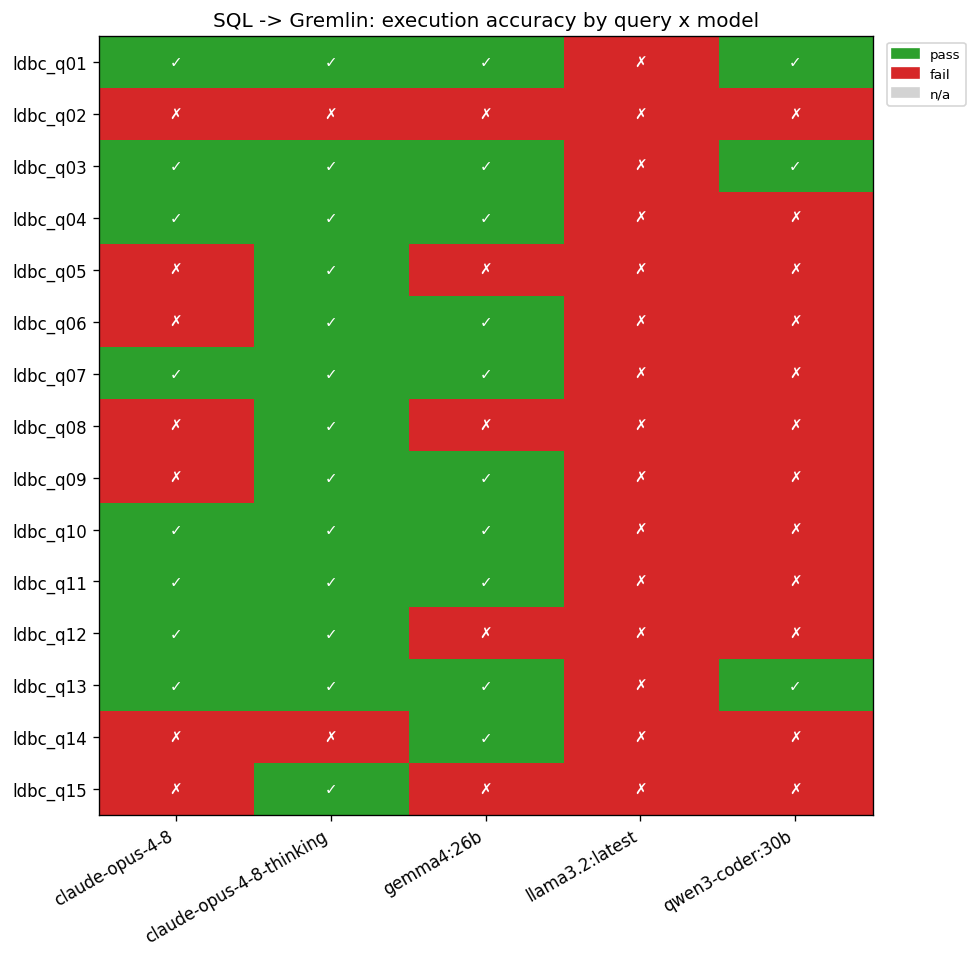

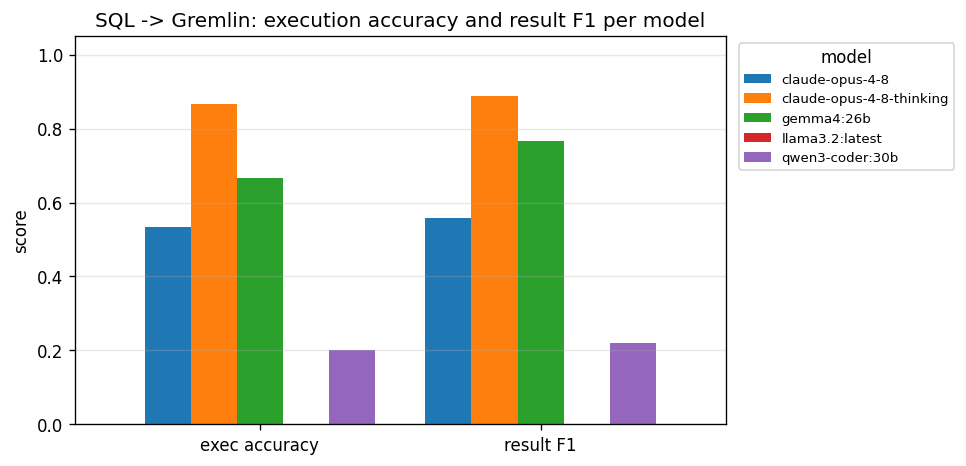

In [38]:
gremlin_exec_df = pd.concat(gremlin_frames, ignore_index=True) if gremlin_frames else None
plots.render_target(gremlin_exec_df, 'gremlin', 'SQL -> Gremlin', plots.FIGURE_SETS['execution'])

### Aggregation by model

In [39]:
summarize_target(gremlin_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
claude-opus-4-8,0.533333,0.557669,0.557669,0.557669,0.452493
claude-opus-4-8-thinking,0.866667,0.887669,0.887669,0.887669,0.120869
gemma4:26b,0.666667,0.762971,0.824263,0.767455,0.247264
llama3.2:latest,0.000000,0.000000,0.000000,0.000000,1.000000
qwen3-coder:30b,0.200000,0.221002,0.221002,0.221002,0.787536


## Run-level summary and save

Merges this pass's per-target frames into `metrics_execution.csv`: rows belonging to targets that were executed are replaced, all other targets' rows are kept as-is.

In [40]:
new_frames = {t: f for t, f in (('cypher', cypher_exec_df), ('aql', aql_exec_df),
                                ('gremlin', gremlin_exec_df)) if f is not None}
if OUT_CSV.exists():
    exec_all = pd.read_csv(OUT_CSV)
    exec_all = exec_all[~exec_all['target'].isin(new_frames)]
else:
    exec_all = pd.DataFrame()
frames = ([exec_all] if len(exec_all) else []) + [f for f in new_frames.values() if len(f)]
exec_all = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

metric_cols = ['execution_accuracy','result_precision','result_recall','result_f1','result_jaccard_dist']
if len(exec_all):
    print('By dataset x target x model:')
    display(exec_all.groupby(['dataset','target','model'])[metric_cols].mean())
exec_all.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(exec_all)} rows to {OUT_CSV} "
      f"(executed this pass: {', '.join(new_frames) or 'none'}; other targets' rows preserved).")
ex.close_clients()

By dataset x target x model:


execution_accuracy  \
dataset target  model                                          
ldbc    aql     claude-opus-4-8                     0.933333   
                claude-opus-4-8-thinking            0.933333   
                gemma4:26b                          0.933333   
                llama3.2:latest                     0.000000   
                qwen3-coder:30b                     0.466667   
        cypher  claude-opus-4-8                     1.000000   
                claude-opus-4-8-thinking            1.000000   
                gemma4:26b                          1.000000   
                llama3.2:latest                     0.200000   
                qwen3-coder:30b                     0.533333   
        gremlin claude-opus-4-8                     0.533333   
                claude-opus-4-8-thinking            0.866667   
                gemma4:26b                          0.666667   
                llama3.2:latest                     0.000000   
                qwen3-coder:30b                     0.200000   

                                          result_precision  result_recall  \
dataset target  model                                                       
ldbc    aql     claude-opus-4-8                   0.933333       0.933333   
                claude-opus-4-8-thinking          0.933333       0.933333   
                gemma4:26b                        0.933333       0.933333   
                llama3.2:latest                   0.000000       0.000000   
                qwen3-coder:30b                   0.466667       0.466667   
        cypher  claude-opus-4-8                   1.000000       1.000000   
                claude-opus-4-8-thinking          1.000000       1.000000   
                gemma4:26b                        1.000000       1.000000   
                llama3.2:latest                   0.208120       0.208120   
                qwen3-coder:30b                   0.563676       0.563676   
        gremlin claude-opus-4-8                   0.557669       0.557669   
                claude-opus-4-8-thinking          0.887669       0.887669   
                gemma4:26b                        0.762971       0.824263   
                llama3.2:latest                   0.000000       0.000000   
                qwen3-coder:30b                   0.221002       0.221002   

                                          result_f1  result_jaccard_dist  
dataset target  model                                                     
ldbc    aql     claude-opus-4-8            0.933333             0.066667  
                claude-opus-4-8-thinking   0.933333             0.066667  
                gemma4:26b                 0.933333             0.066667  
                llama3.2:latest            0.000000             1.000000  
                qwen3-coder:30b            0.466667             0.533333  
        cypher  claude-opus-4-8            1.000000             0.000000  
                claude-opus-4-8-thinking   1.000000             0.000000  
                gemma4:26b                 1.000000             0.000000  
                llama3.2:latest            0.208120             0.795677  
                qwen3-coder:30b            0.563676             0.449010  
        gremlin claude-opus-4-8            0.557669             0.452493  
                claude-opus-4-8-thinking   0.887669             0.120869  
                gemma4:26b                 0.767455             0.247264  
                llama3.2:latest            0.000000             1.000000  
                qwen3-coder:30b            0.221002             0.787536

Wrote 225 rows to /Users/ivona.obonova/school/sql2graph/sql2graph/eval/outputs/metrics/metrics_execution.csv (executed this pass: cypher, aql, gremlin; other targets' rows preserved).
